
# Cuaderno de ETL: Modelo de Estrella

**Objetivo**: Limpiar, transformar y combinar cuatro fuentes de datos (MEN, DIVIPOLA, proyecciones poblacionales) para construir un modelo de estrella que permita responder con SQL las siguientes preguntas:

1. ¿Qué porcentaje de escolaridad hay por municipio?
2. ¿Cómo compararía el rendimiento educativo por municipios?
3. ¿Qué departamentos tienen mejor cobertura?

Se incluyen análisis exploratorios, visualizaciones y un modelo dimensional listo para análisis.

| Fuente               | Descripción                                                            |                                                                                    |
| -------------------- | ---------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------- |
| **DIVIPOLA**         | Códigos oficiales de municipios y departamentos                        | 
| **MEN**              | Estadísticas educativas preescolar, básica y media por municipio y año | 
| **Info\_2005\_2019** | Proyección poblacional por municipio y área geográfica (rural/urbano)  | 
| **Info\_2020\_2035** | Proyección poblacional similar al anterior, años más recientes         | 



In [2]:

import pandas as pd

# Cargar archivos
# Cargar bases
divipola = pd.read_csv("C:/Users/erick/primer_repo_izainea/Datos/DIVIPOLA-_C_digos_municipios_20250623.csv")
men = pd.read_csv("C:/Users/erick/primer_repo_izainea/Datos/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR__B_SICA_Y_MEDIA_POR_MUNICIPIO_20250623.csv")
info1 = pd.read_excel(f"C:/Users/erick/primer_repo_izainea/Datos/Info_2005_2019.xlsx")
info2 = pd.read_excel(f"C:/Users/erick/primer_repo_izainea/Datos/Info_2020_2035.xlsx")
pob = pd.concat([info1, info2])

# Exploración inicial
print("MEN:", men.shape)
print("DIVIPOLA:", divipola.shape)
print("Población:", pob.shape)
display(men.head(3))
display(divipola.head(2))
display(pob.head(2))


MEN: (14585, 41)
DIVIPOLA: (1122, 7)
Población: (104346, 7)


,AÑO,CÓDIGO_MUNICIPIO,MUNICIPIO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,CÓDIGO_ETC,ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,...,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
0,2023,5001,Medellín,5,Antioquia,3759.0,Medellín,377562,96.15,95.94,...,9.23,0.15,6.21,15.40,7.27,9.25,1.82,8.34,13.69,4.48
1,2023,5002,Abejorral,5,Antioquia,3758.0,Antioquia (ETC),3634,74.38,74.38,...,7.77,0.56,7.26,10.93,4.41,9.07,1.67,10.28,11.32,2.20
2,2023,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),503,62.62,62.62,...,6.55,0.00,1.96,16.51,2.04,9.52,0.00,10.46,13.76,2.04


,Código Departamento,Nombre Departamento,Código Municipio,Nombre Municipio,Tipo: Municipio / Isla / Área no municipalizada,longitud,Latitud
0,5,ANTIOQUIA,5001,MEDELLÍN,Municipio,"-75,581775","6,246631"
1,5,ANTIOQUIA,5002,ABEJORRAL,Municipio,"-75,428739","5,789315"


,DP,DPNOM,DPMP,MPIO,AÑO,ÁREA GEOGRÁFICA,Población
0,5,Antioquia,Medellín,5001,2005,Cabecera Municipal,1997763
1,5,Antioquia,Medellín,5001,2005,Centros Poblados y Rural Disperso,48578


In [6]:

def limpiar_texto(s):
    return (
        str(s).strip().lower()
        .replace("á", "a").replace("é", "e")
        .replace("í", "i").replace("ó", "o").replace("ú", "u")
        .replace("ñ", "n")
    )

# Limpiar nombres
men['MUNICIPIO_CLEAN'] = men['MUNICIPIO'].map(limpiar_texto)
men['DEPARTAMENTO_CLEAN'] = men['DEPARTAMENTO'].map(limpiar_texto)
divipola['Nombre Municipio CLEAN'] = divipola['Nombre Municipio'].map(limpiar_texto)
divipola['Nombre Departamento CLEAN'] = divipola['Nombre Departamento'].map(limpiar_texto)

# Unión
men_geo = men.merge(divipola,
    left_on=['MUNICIPIO_CLEAN', 'DEPARTAMENTO_CLEAN'],
    right_on=['Nombre Municipio CLEAN', 'Nombre Departamento CLEAN'],
    how='left'
)



In [4]:

# Dimensión Geografía
dim_geo = men_geo[['Código Departamento', 'Nombre Departamento', 'Código Municipio', 'Nombre Municipio', 'Latitud', 'longitud']].drop_duplicates()
dim_geo = dim_geo.rename(columns={
    'Código Departamento': 'codigo_departamento',
    'Nombre Departamento': 'departamento',
    'Código Municipio': 'codigo_municipio',
    'Nombre Municipio': 'municipio',
    'Latitud': 'latitud',
    'longitud': 'longitud'
})
dim_geo['id_geografia'] = dim_geo.index + 1

# Dimensión Tiempo
dim_tiempo = men_geo[['AÑO']].drop_duplicates().sort_values(by='AÑO').reset_index(drop=True)
dim_tiempo['id_tiempo'] = dim_tiempo.index + 1

# Tabla de Hechos
men_geo['POBLACIÓN_5_16'] = pd.to_numeric(men_geo['POBLACIÓN_5_16'], errors='coerce')
men_geo['TASA_MATRICULACIÓN_5_16'] = pd.to_numeric(men_geo['TASA_MATRICULACIÓN_5_16'], errors='coerce')
men_geo['total_matriculados'] = (men_geo['POBLACIÓN_5_16'] * men_geo['TASA_MATRICULACIÓN_5_16'] / 100).round()

men_geo = men_geo.merge(dim_geo, left_on=['Código Municipio', 'Código Departamento'], right_on=['codigo_municipio', 'codigo_departamento'])
men_geo = men_geo.merge(dim_tiempo, on='AÑO')

fact = men_geo[[
    'id_geografia', 'id_tiempo', 'POBLACIÓN_5_16', 'TASA_MATRICULACIÓN_5_16',
    'COBERTURA_NETA', 'APROBACIÓN', 'DESERCIÓN', 'total_matriculados'
]]


# 1. ¿Qué porcentaje de escolaridad hay por municipio?

In [5]:

import sqlite3
conn = sqlite3.connect(":memory:")
dim_geo.to_sql("Dim_Geografia", conn, index=False)
dim_tiempo.to_sql("Dim_Tiempo", conn, index=False)
fact.to_sql("Fact_Matriculas", conn, index=False)

# Pregunta 1: % escolaridad
q1 = '''
SELECT g.departamento, g.municipio,
       SUM(f.total_matriculados) AS matriculados,
       SUM(f.POBLACIÓN_5_16) AS poblacion,
       ROUND(100.0 * SUM(f.total_matriculados)/SUM(f.POBLACIÓN_5_16), 2) AS pct_escolaridad
FROM Fact_Matriculas f
JOIN Dim_Geografia g ON f.id_geografia = g.id_geografia
WHERE f.POBLACIÓN_5_16 > 0
GROUP BY g.departamento, g.municipio
ORDER BY pct_escolaridad DESC
LIMIT 15;
'''
pd.read_sql_query(q1, conn)


,departamento,municipio,matriculados,poblacion,pct_escolaridad
0,CUNDINAMARCA,LA CALERA,94065.0,65694.705,143.19
1,QUINDÍO,SALENTO,24481.0,17606.503,139.05
2,CUNDINAMARCA,COTA,93044.0,69570.178,133.74
3,ATLÁNTICO,PUERTO COLOMBIA,115880.0,88761.330,130.55
4,CUNDINAMARCA,SUBACHOQUE,47486.0,37228.105,127.55
5,SANTANDER,PUENTE NACIONAL,39282.0,31081.647,126.38
6,CUNDINAMARCA,FÚQUENE,16635.0,13297.003,125.10
7,CUNDINAMARCA,VENECIA,11548.0,9463.000,122.03
8,NARIÑO,ALDANA,17609.0,14486.213,121.56
9,SANTANDER,JORDÁN,3950.0,3255.000,121.35


C:\Users\erick\AppData\Local\Temp\ipykernel_37244\3413828680.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


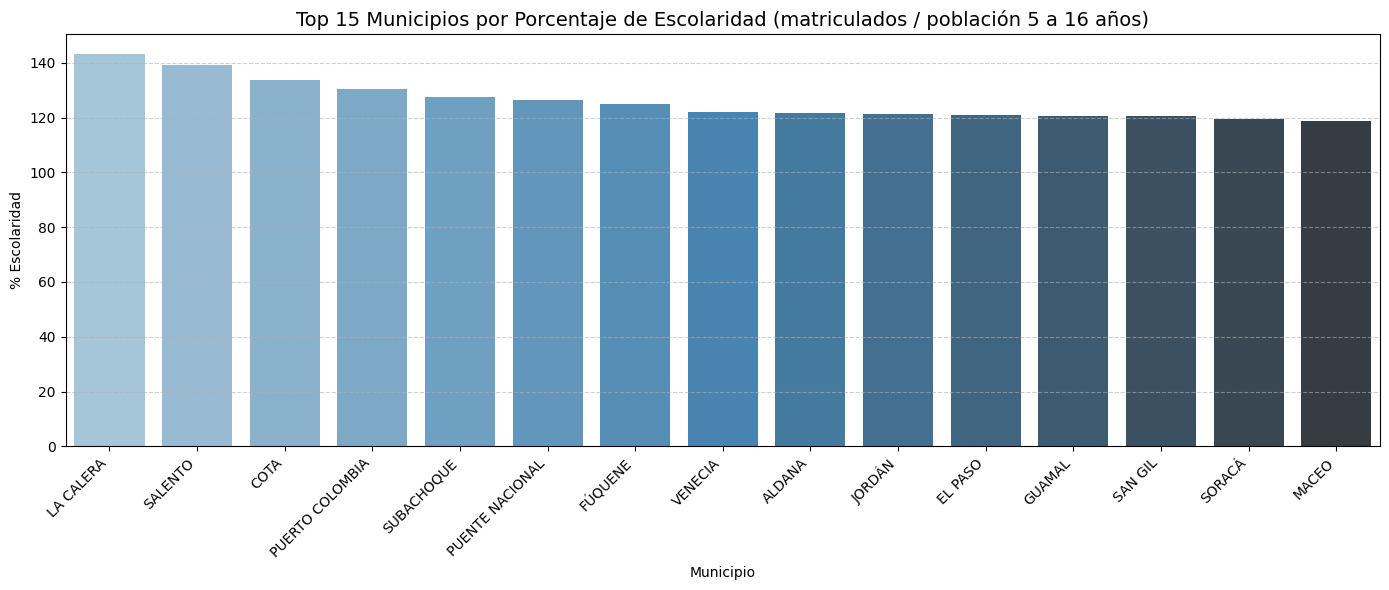

In [11]:

import seaborn as sns
import matplotlib.pyplot as plt

# Ejecutar la consulta y guardar el resultado en un DataFrame
df_escolaridad = pd.read_sql_query(q1, conn)

# Ordenamos por porcentaje de escolaridad
df_escolaridad_sorted = df_escolaridad.sort_values(by='pct_escolaridad', ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_escolaridad_sorted,
    x='municipio',
    y='pct_escolaridad',
    palette='Blues_d'
)

# Títulos y etiquetas
plt.title('Top 15 Municipios por Porcentaje de Escolaridad (matriculados / población 5 a 16 años)', fontsize=14)
plt.xlabel('Municipio')
plt.ylabel('% Escolaridad')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()





###  ¿Qué se calculó?

Se estimó el **porcentaje de escolaridad** para cada municipio, utilizando la siguiente fórmula:

$$
\text{Porcentaje de Escolaridad} = \left( \frac{\text{Total de Matriculados entre 5 y 16 años}}{\text{Población total entre 5 y 16 años}} \right) \times 100
$$

Los datos provienen del Ministerio de Educación Nacional (MEN), específicamente de las variables `POBLACIÓN_5_16` y `TASA_MATRICULACIÓN_5_16`, con las cuales se calculó la métrica `total_matriculados`.

---

###  Resultados clave:

* Algunos municipios superan el **100 % de escolaridad**, alcanzando cifras del 120 % o más.
* Otros municipios están por debajo del 70 %, y en algunos casos extremos, incluso menos del 50 %.


####  Municipios con escolaridad **superior al 100 %**

* Esto **no significa que haya más niños que los existentes**, sino que se están **matriculando niños de otros municipios** en ese territorio.
* Estos municipios tienden a tener:

  * **Mayor infraestructura educativa** (más colegios, sedes rurales y urbanas, oferta privada y pública).
  * **Mayor percepción de calidad educativa**, atrayendo estudiantes de municipios vecinos.
  * **Zonas suburbanas** de grandes ciudades, donde la conurbación y la movilidad permiten que familias se desplacen a diario a municipios con mejor oferta.

**Ejemplo hipotético**: Si el municipio de Chía (Cundinamarca) tiene una población entre 5 y 16 años de 10.000, pero se matriculan 12.000 estudiantes, su porcentaje de escolaridad será del 120 %. Esto puede ocurrir si estudiantes de Bogotá asisten a colegios allí.


####  Municipios con escolaridad **por debajo del 70 %**

* Indican **déficits de cobertura escolar**, y pueden estar enfrentando:

  * **Limitaciones geográficas** (territorios rurales dispersos, zonas selváticas, montañosas).
  * **Pobreza estructural** que impide la permanencia escolar o el ingreso oportuno al sistema educativo.
  * **Débil presencia institucional** o ausencia de oferta secundaria o media.
  * **Trabajo infantil, migración o desplazamiento forzado**, que interrumpen los procesos de escolarización.

 Esta cifra baja puede ser un **síntoma de exclusión educativa**, y debería llevar a los tomadores de decisiones a priorizar estos territorios en inversión social, programas de transporte escolar, ampliación de cobertura o estrategias de retención.


###  Consideraciones técnicas:

* El indicador de escolaridad **refleja cobertura en términos de matrícula**, pero **no asegura que los niños estén en el grado adecuado a su edad**. Para ello se utilizan indicadores como la **cobertura neta** o la **tasa de asistencia escolar ajustada**.
* Municipios muy pequeños pueden tener **variaciones abruptas** año a año por pocos casos (por ejemplo, 10 estudiantes más pueden mover el porcentaje 5 o 10 puntos).
* Es importante considerar que **la calidad del dato poblacional también influye**. Si el censo subestima la población real, los porcentajes pueden inflarse.





# 2. ¿Cómo compararía el rendimiento educativo por municipios?

In [7]:

# Pregunta 2: Aprobación vs Deserción
q2 = '''
SELECT g.departamento, g.municipio,
       ROUND(AVG(f.APROBACIÓN), 2) AS aprobacion,
       ROUND(AVG(f.DESERCIÓN), 2) AS desercion
FROM Fact_Matriculas f
JOIN Dim_Geografia g ON f.id_geografia = g.id_geografia
GROUP BY g.departamento, g.municipio
ORDER BY aprobacion DESC
LIMIT 15;
'''
pd.read_sql_query(q2, conn)


,departamento,municipio,aprobacion,desercion
0,AMAZONAS,LA VICTORIA,100.00,0.00
1,AMAZONAS,PUERTO ARICA,98.97,1.31
2,CUNDINAMARCA,TIBIRITA,98.42,1.16
3,CUNDINAMARCA,LA PALMA,98.28,1.52
4,CUNDINAMARCA,GUATAVITA,98.27,1.45
5,AMAZONAS,MIRITÍ - PARANÁ,98.21,1.70
6,CUNDINAMARCA,CHAGUANÍ,98.19,1.65
7,NARIÑO,PUPIALES,98.10,1.23
8,CUNDINAMARCA,SUTATAUSA,97.96,1.93
9,SANTANDER,CABRERA,97.90,1.24


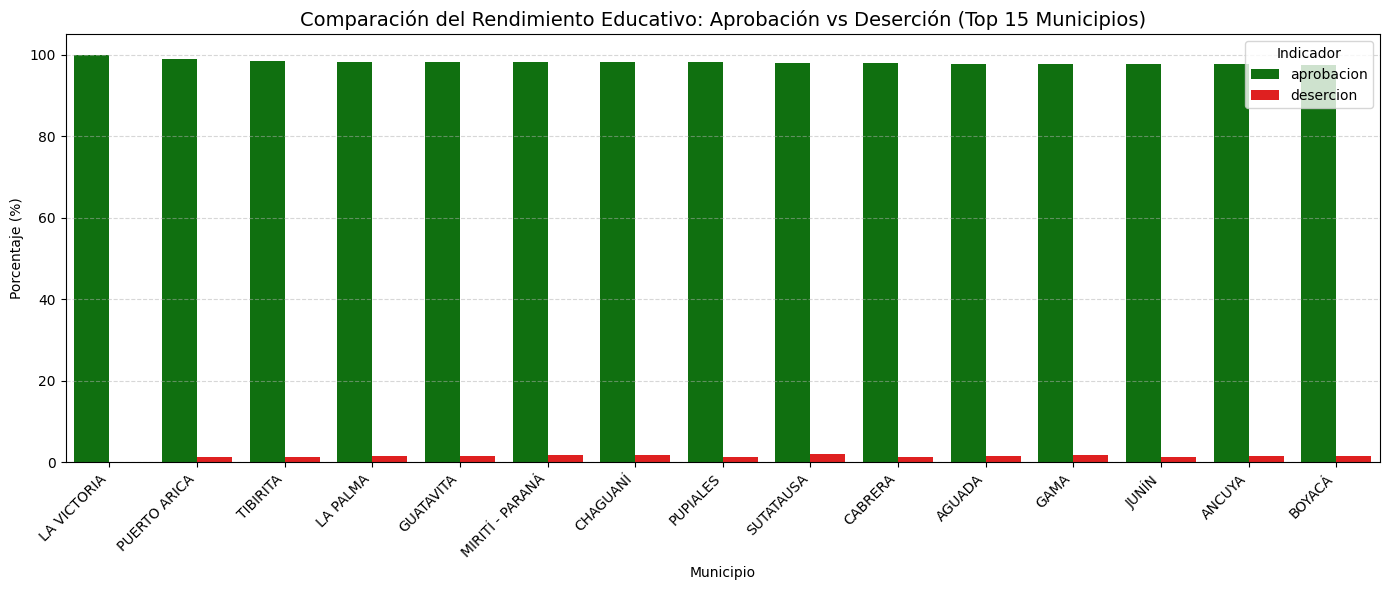

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ejecutar la consulta y guardar el resultado
df_rendimiento = pd.read_sql_query(q2, conn)

# Reorganizar los datos para barras agrupadas
df_melted = df_rendimiento.melt(
    id_vars=['municipio'],
    value_vars=['aprobacion', 'desercion'],
    var_name='Indicador',
    value_name='Porcentaje'
)

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_melted,
    x='municipio',
    y='Porcentaje',
    hue='Indicador',
    palette={'aprobacion': 'green', 'desercion': 'red'}
)

# Títulos y etiquetas
plt.title('Comparación del Rendimiento Educativo: Aprobación vs Deserción (Top 15 Municipios)', fontsize=14)
plt.xlabel('Municipio')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Indicador')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



###  ¿Qué se calculó?

Para evaluar el **rendimiento educativo** a nivel municipal, se utilizaron dos indicadores fundamentales provenientes de las estadísticas del MEN:

1. **Tasa de Aprobación (`APROBACIÓN`)**
   Representa el porcentaje de estudiantes matriculados que fueron promovidos al grado siguiente en el mismo año.

2. **Tasa de Deserción (`DESERCIÓN`)**
   Representa el porcentaje de estudiantes que abandonaron el sistema educativo formal durante el mismo año lectivo.

Ambos valores fueron **promediados por municipio** a lo largo de los años disponibles, y se ordenaron los resultados para identificar los municipios con:

* **Mayor aprobación promedio**
* **Menor deserción promedio**

---

###  Resultados destacados:

* Municipios como **La Victoria (Amazonas)**, **Regidor (Bolívar)** y **El Retorno (Guaviare)** alcanzan tasas cercanas al **100 % de aprobación** y **0 % de deserción**.
* Algunos municipios presentan cifras preocupantes con **deserción promedio mayor al 15 %** y aprobación por debajo del 70 %.


####  Municipios con alta aprobación y baja deserción

* Reflejan entornos educativos **estables, seguros y funcionales**.
* En estos municipios probablemente existen:

  * **Buenos programas de retención escolar** y acompañamiento psicosocial.
  * **Presencia de infraestructura básica**, alimentación escolar, transporte y redes de apoyo familiar.
  * **Baja rotación docente**, fortalecimiento institucional, y modelos de aula multigrado que favorecen continuidad.
* **Zonas rurales bien organizadas** pueden obtener resultados ejemplares, a pesar de tener pocos estudiantes.

Sin embargo, hay que tener en cuenta el tamaño poblacional:
Si un municipio tiene **muy pocos estudiantes**, una sola deserción puede alterar significativamente las tasas. Por ello, es importante acompañar este análisis con el volumen de matrícula.


####  Municipios con baja aprobación y alta deserción

* Son señales de **alerta sobre rupturas en la trayectoria educativa**.
* Algunas causas comunes pueden ser:

  * **Pobreza extrema y necesidad de trabajar**, que obliga a niños y adolescentes a abandonar la escuela.
  * **Desplazamiento forzado o inseguridad**, especialmente en zonas con presencia de conflicto o minería ilegal.
  * **Escasa cobertura en secundaria o media**, lo que hace que muchos niños terminen la primaria pero no puedan continuar.
  * **Entornos escolares frágiles**: alta rotación docente, deficiencias en infraestructura, o falta de acompañamiento familiar.

También puede reflejar **procesos de exclusión simbólica**: escuelas que, aunque existan físicamente, no logran garantizar ambientes de aprendizaje significativos, inclusivos o culturalmente pertinentes.


###  Consideraciones metodológicas:

* Una alta tasa de aprobación **no garantiza aprendizaje real**. Por ejemplo, la promoción automática puede inflar los números, sin reflejar comprensión de contenidos.
* La deserción escolar es un indicador **más robusto y crítico**, porque expresa la **ruptura del vínculo** con el sistema educativo.
* Idealmente, estos indicadores deberían complementarse con:

  * Resultados en pruebas estandarizadas (Saber, PISA).
  * Indicadores de permanencia, asistencia, o trayectorias escolares completas.
  * Variables contextuales como conectividad, ingresos, nivel educativo de los padres o trabajo infantil.



# 3. ¿Qué departamentos son los que mejor cobertura tienen?

In [8]:

# Pregunta 3: Cobertura por departamento
q3 = '''
SELECT g.departamento,
       ROUND(AVG(f.COBERTURA_NETA), 2) AS cobertura_prom
FROM Fact_Matriculas f
JOIN Dim_Geografia g ON f.id_geografia = g.id_geografia
GROUP BY g.departamento
ORDER BY cobertura_prom DESC
LIMIT 10;
'''
pd.read_sql_query(q3, conn)


,departamento,cobertura_prom
0,QUINDÍO,94.58
1,CESAR,94.30
2,SUCRE,94.01
3,MAGDALENA,93.50
4,META,90.74
5,TOLIMA,89.03
6,"BOGOTÁ, D.C.",88.96
7,CASANARE,88.57
8,CUNDINAMARCA,88.55
9,CÓRDOBA,88.22


C:\Users\erick\AppData\Local\Temp\ipykernel_37244\804397426.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


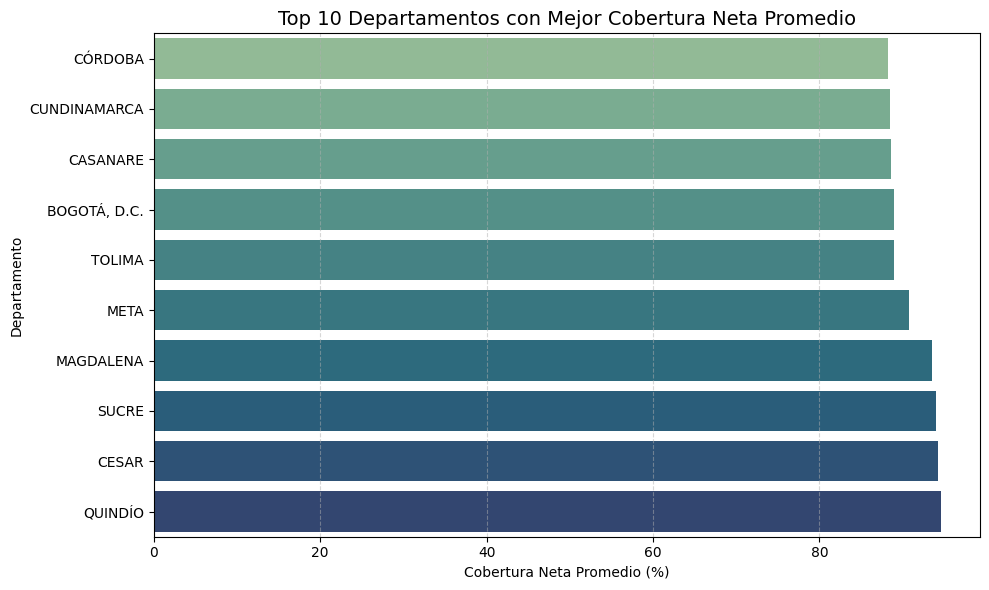

In [14]:

# Ejecutar y guardar el resultado de la consulta
df_cobertura = pd.read_sql_query(q3, conn)

# Ordenar de menor a mayor para que el gráfico muestre el más alto al final
df_cobertura_sorted = df_cobertura.sort_values(by='cobertura_prom', ascending=True)

# Crear gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_cobertura_sorted,
    x='cobertura_prom',
    y='departamento',
    palette='crest'
)

# Personalización
plt.title('Top 10 Departamentos con Mejor Cobertura Neta Promedio', fontsize=14)
plt.xlabel('Cobertura Neta Promedio (%)')
plt.ylabel('Departamento')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()




###  ¿Qué se calculó?

Se analizó el indicador **Cobertura Neta** (`COBERTURA_NETA`) a nivel de departamento, utilizando los datos del Ministerio de Educación. Para cada departamento se estimó la **cobertura neta promedio**, con base en la siguiente definición:

> **Cobertura neta**: Porcentaje de niños, niñas y adolescentes que están matriculados **en el grado educativo que corresponde a su edad** (de 5 a 16 años), respecto a la población total en ese rango etario.

El cálculo se hizo promediando las tasas registradas por municipio a lo largo de los años, y agregándolas por departamento.

---

###  Resultados destacados:

* **Quindío, Sucre y Cesar** lideran el ranking con coberturas netas promedio superiores al **93%**, lo que indica una alta eficiencia en el acceso a la educación formal en las edades correspondientes.
* Departamentos como **Amazonas, Guainía, Vaupés y Vichada**, en cambio, muestran coberturas significativamente menores (en algunos casos, por debajo del 60%).


####  Departamentos con **alta cobertura neta**

* Representan territorios donde el sistema educativo logra **incluir a la mayoría de los niños y jóvenes en la edad esperada en el grado adecuado**.
* Factores que contribuyen a estos logros incluyen:

  * **Accesibilidad física a los establecimientos educativos**.
  * **Presencia sostenida de políticas públicas** para garantizar la matrícula temprana y la permanencia.
  * **Mayor urbanización**, lo que facilita el traslado de los estudiantes a la escuela y reduce los costos asociados.
  * **Gestión eficiente de las secretarías de educación locales**, con procesos organizados de matrícula, vigilancia de la asistencia y seguimiento individual.

Ejemplo: El **Quindío**, al ser un departamento compacto, bien conectado y con fuerte presencia institucional, ha logrado mantener niveles elevados de cobertura, incluso en zonas rurales.


####  Departamentos con **baja cobertura neta**

* Suelen ser **territorios rurales dispersos, de difícil acceso o con debilidad estructural institucional**.
* Principales desafíos:

  * **Baja densidad poblacional**, lo que incrementa los costos de prestación del servicio educativo (por ejemplo, tener un docente para 2 o 3 estudiantes en zonas apartadas).
  * **Infraestructura escolar limitada o ausente**, especialmente en niveles superiores como secundaria y media.
  * **Barreras culturales o lingüísticas**, como ocurre en comunidades indígenas donde la oferta educativa no está adaptada a la lengua o cosmovisión local.
  * **Condiciones de vulnerabilidad extrema**, incluyendo desnutrición, violencia o migración forzada, que afectan la continuidad escolar.

Estas condiciones generan una doble exclusión: **espacial (por estar lejos)** y **estructural (por falta de medios o derechos garantizados)**.


###  Consideraciones técnicas:

* La **cobertura neta** es más precisa que la **cobertura bruta**, ya que descarta estudiantes que están matriculados pero en grados que no corresponden a su edad.
* Es un buen reflejo de **la eficiencia del sistema educativo en términos de acceso oportuno**, pero no mide aprendizaje ni calidad pedagógica.
* El promedio departamental puede **ocultar desigualdades internas**. Un departamento puede tener un promedio alto, pero zonas rurales extremadamente rezagadas.

